In [1]:
import pyarrow.parquet as pq
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import IterableDataset, DataLoader
from tqdm import tqdm

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import  accuracy_score, classification_report
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
import torch.nn.functional as F

## Config

In [2]:
# ---------------------------------------
# Configuration
# ---------------------------------------
parquet_path = 'MasterDS/Master_cleaned.parquet'
return_col   = 'ret_5d_future' # Column to predict
batch_size   = 4096
n_epochs     = 15  # number of training epochs
device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ---------------------------------------
# Prepare ParquetFile and feature columns
# ---------------------------------------
pf = pq.ParquetFile(parquet_path)
all_cols = pf.schema_arrow.names
exclude  = {return_col, 'date', 'ticker'}
feature_cols = [c for c in all_cols if c not in exclude]

#Get unique tickers
# 1) Collect unique tickers
unique_tickers = set()
for rg in range(pf.num_row_groups):
    df_rg = pf.read_row_group(rg, columns=["ticker"]).to_pandas()
    unique_tickers.update(df_rg["ticker"].unique())

# 2) Sort (optional, but reproducible) and map to IDs
unique_tickers = sorted(unique_tickers)
ticker_id_map   = {t: i for i, t in enumerate(unique_tickers)}
ticker_vocab    = len(unique_tickers)

print(f"Found {ticker_vocab} unique tickers")


# ---------------------------------------
# Precompute date-wise cutoff map
# ---------------------------------------
cutoff_lists, all_dates = {}, set()
for batch in pf.iter_batches(batch_size=1_500_000):
    dfb = batch.to_pandas()[['date', return_col]]
    for date, grp in dfb.groupby('date'):
        all_dates.add(date)
        cutoff_lists.setdefault(date, []).extend(grp[return_col].values)
cutoff_map = {date: np.quantile(vals, 0.95) for date, vals in cutoff_lists.items()}
all_dates = sorted(all_dates)
n_total = len(all_dates)
train_idx = int(n_total * 0.8) # 80% for training, 20% for testing

train_dates = set(all_dates[:train_idx])
test_dates  = set(all_dates[train_idx:])


# ---------------------------------------
# Fit scaler on a sample group of rows
# ---------------------------------------

calib_frames = []
n_groups = min(20, pf.num_row_groups)
for i in range(n_groups):
    # grab a small random sample from each row-group
    df_rg = pf.read_row_group(i).to_pandas()[feature_cols]
    calib_frames.append(df_rg.sample(n=5000, random_state=42))

calib = pd.concat(calib_frames, axis=0)
feature_scaler = StandardScaler().fit(calib.values)

# ---------------------------------------
# Define IterableDataset for streaming
# ---------------------------------------
class ParquetDataset(IterableDataset):
    """
    Streams batches from the Parquet file without any class-balancing.
    Each yielded tuple is (xb, yb, meta) where:
        xb   : torch.FloatTensor  [batch_size, n_features]
        yb   : torch.FloatTensor  [batch_size]   (0/1 labels)
        meta : np.ndarray         [batch_size, 2]  (date, ticker)
    """
    def __init__(self, dates_subset, pos_ratio=None, batch_size=4096):
        self.dates_subset = dates_subset
        self.pos_ratio = pos_ratio
        self.batch_size = batch_size

    def __iter__(self):
        local_pf = pq.ParquetFile(parquet_path)

        for batch in local_pf.iter_batches(batch_size=self.batch_size * 4):
            df = batch.to_pandas()
            df = df[df["date"].isin(self.dates_subset)]
            if df.empty:
                continue

            # create label
            df["label"] = (df[return_col] >= df["date"].map(cutoff_map)).astype(np.int8)

            # filter finite rows
            X_raw = df[feature_cols].values.astype(np.float32)
            y_raw = df["label"].values.astype(np.int8)
            mask  = np.isfinite(X_raw).all(axis=1)
            if not mask.any():
                continue

            X     = feature_scaler.transform(X_raw[mask])
            X = np.clip(X, -5.0, +5.0)
            y     = y_raw[mask]
            meta  = df.loc[mask, ["date", "ticker"]].values

            if self.pos_ratio is not None:
                idx_pos = np.where(y == 1)[0]
                idx_neg = np.where(y == 0)[0]

                if len(idx_pos) == 0 or len(idx_neg) == 0:
                    continue  # skip batch if only one class

                n_pos = int(self.batch_size * self.pos_ratio)
                n_neg = self.batch_size - n_pos

                choose_pos = np.random.choice(idx_pos, n_pos, replace=len(idx_pos) < n_pos)
                choose_neg = np.random.choice(idx_neg, n_neg, replace=len(idx_neg) < n_neg)

                sel = np.concatenate([choose_pos, choose_neg])
                np.random.shuffle(sel)

                X, y, meta = X[sel], y[sel], meta[sel]
            else:
                if len(y) > self.batch_size:
                    sel = np.random.choice(len(y), self.batch_size, replace=False)
                    X, y, meta = X[sel], y[sel], meta[sel]

            # convert to tensors
            xb = torch.from_numpy(X).to(device)
            yb = torch.from_numpy(y.astype(np.float32)).to(device)

            yield xb, yb, meta

class FeatureTokenizer(nn.Module):
    """
    Projects each numeric feature into d_model‐dim tokens and
    adds a learned column embedding (like a 'positional encoding').
    """
    def __init__(self, num_features: int, d_model: int, ticker_vocab: int | None = None):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(num_features, d_model))
        self.bias   = nn.Parameter(torch.zeros(num_features, d_model))
        nn.init.trunc_normal_(self.weight, std=0.02)

        # learned column embeddings
        self.col_embed = nn.Parameter(torch.randn(num_features, d_model) * 0.02)

        # optional ticker embedding appended as an extra token
        if ticker_vocab is not None:
            self.ticker_emb = nn.Embedding(ticker_vocab, d_model)
            self.with_ticker = True
        else:
            self.with_ticker = False

    def forward(self, x_num: torch.Tensor, ticker_id: torch.Tensor | None = None):
        """
        x_num : (B, F)  – scaled numeric features
        ticker_id: (B,) – integer id per row
        returns tokens (B, N_tok, d_model)
        """
        tok = x_num.unsqueeze(-1) * self.weight + self.bias          # (B, F, d_model)
        tok = tok + self.col_embed                                   # column encoding

        if self.with_ticker:
            tick_tok = self.ticker_emb(ticker_id).unsqueeze(1)       # (B, 1, d_model)
            tok = torch.cat([tick_tok, tok], dim=1)                  # prepend ticker token
        return tok


class FTTransformer(nn.Module):
    """
    Feature-token Transformer for tabular data (Gorishniy et al., 2021).
    """
    def __init__(
        self,
        num_features: int,
        d_model: int = 64,
        n_heads: int = 8,
        depth: int = 4,
        mlp_ratio: float = 2.0,
        dropout: float = 0.2,
        ticker_vocab: int | None = None,
    ):
        super().__init__()
        self.tokenizer = FeatureTokenizer(num_features, d_model, ticker_vocab)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=int(d_model * mlp_ratio),
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        self.cls_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1)   # logits
        )

    def forward(self, x_num: torch.Tensor, ticker_id: torch.Tensor | None = None):
        """
        x_num : (B, F)
        ticker_id : (B,) or None
        """
        tok = self.tokenizer(x_num, ticker_id)               # (B, N_tok, d_model)
        h   = self.encoder(tok)                              # (B, N_tok, d_model)
        cls = h[:, 0] if self.tokenizer.with_ticker else h.mean(dim=1)
        return self.cls_head(cls).squeeze(1)                 # (B,)

class FocalLoss(nn.Module):
    """
    Focal Loss for binary classification
      L = - alpha * (1 - p_t)^gamma * log(p_t)
    where p_t = sigmoid(logits) if y=1, or 1 - sigmoid(logits) if y=0.
    """

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, reduction: str = "mean"):
        """
        Args:
            alpha: weight for the positive class (in [0,1])
            gamma: focusing parameter (>=0)
            reduction: 'none' | 'mean' | 'sum'
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits: raw network output of shape [B]
            targets: binary labels (0 or 1) of shape [B]
        Returns:
            loss: scalar (if reduction!='none') or per-sample loss [B]
        """
        # compute binary cross entropy per sample
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")  # [B]

        # p_t = sigmoid(logits) when y=1, else 1 - sigmoid(logits)
        prob = torch.sigmoid(logits)
        p_t = targets * prob + (1 - targets) * (1 - prob)

        # focal weight factor
        weight = self.alpha * (1 - p_t).pow(self.gamma)

        loss = weight * bce

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:  # 'none'
            return loss
        
class AUCMarginLoss(nn.Module):
    def __init__(self, margin: float = 0.15):
        super().__init__()
        self.margin = margin
    def forward(self, logits, targets):
        pos = logits[targets==1]
        neg = logits[targets==0]
        if len(pos)==0 or len(neg)==0:
            return logits.new_tensor(0.)
        diff = neg.view(-1,1) - pos.view(1,-1) + self.margin
        return torch.relu(diff).mean()

Using device: cuda
Found 11526 unique tickers


## Train

In [ ]:
# ---------------------------------------
# 1) DataLoader & balancing
# ---------------------------------------
train_ds = ParquetDataset(train_dates, pos_ratio=0.05, batch_size=batch_size)
scan_loader = DataLoader(train_ds, batch_size=None, num_workers=0)

# criterion = FocalLoss(alpha=alpha, gamma=gamma, reduction="mean")
criterion = AUCMarginLoss(margin=0.2)

# estimate steps (needed for OneCycleLR)
total_rows = sum(pf.metadata.row_group(i).num_rows for i in range(pf.num_row_groups))
train_steps = int((total_rows * 0.8) // batch_size)

train_loader = DataLoader(train_ds, batch_size=None, num_workers=0)

# ---------------------------------------
# 2) FT-Transformer instantiation
# ---------------------------------------
d_model      = 128
n_heads      = 8
depth        = 6
dropout      = 0.5
ticker_vocab = len(unique_tickers)   # build this mapping once from your master DataFrame

model = FTTransformer(
    num_features=len(feature_cols),
    d_model=d_model,
    n_heads=n_heads,
    depth=depth,
    dropout=dropout,
    ticker_vocab=ticker_vocab
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    steps_per_epoch=train_steps,
    epochs=n_epochs,
    pct_start=0.2,
)

scaler = GradScaler()

# ---------------------------------------
# 3) Training loop
# ---------------------------------------
for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    n_batches    = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
    for xb, yb, meta in pbar:
        # meta[:,1] is your ticker strings → map to IDs
        tick_ids = torch.tensor(
            [ticker_id_map[t] for t in meta[:,1]],
            dtype=torch.long,
            device=device
        )

        optimizer.zero_grad(set_to_none=True)
        with autocast(device_type=device.type, dtype=torch.float16):
            logits = model(xb, tick_ids)
            loss   = criterion(logits.clamp(-10,10), yb)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        running_loss += loss.item()
        n_batches    += 1
        pbar.set_postfix(loss=running_loss/n_batches)

    print(f"→ Epoch {epoch+1} avg loss: {running_loss/n_batches:.4f}")

# ---------------------------------------
# 4) Save
# ---------------------------------------
torch.save(model.state_dict(), "models/TopSelector_state_dict.pt")
model.eval()

# build a dummy input (batch size 1) for saving full model
dummy_x    = torch.randn(1, len(feature_cols), device=device)
dummy_tick = torch.tensor([0], dtype=torch.long, device=device)

traced = torch.jit.trace(
    model,
    (dummy_x, dummy_tick),
    check_trace=False
)
traced.save("models/TopSelector.pt")
print("Saved traced model at models/TopSelector.pt")

C:\Users\taren\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Epoch 1/15: 0it [00:00, ?it/s]C:\Users\taren\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:182: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Epoch 1/15: 422it [03:49,  1.84it/s, loss=0.222]


→ Epoch 1 avg loss: 0.2221


Epoch 2/15: 422it [03:45,  1.87it/s, loss=0.154]


→ Epoch 2 avg loss: 0.1537


Epoch 3/15: 422it [03:45,  1.87it/s, loss=0.137]


...

Epoch 7/15: 422it [04:46,  1.47it/s, loss=0.115]


→ Epoch 7 avg loss: 0.1152


Epoch 8/15: 422it [05:00,  1.41it/s, loss=0.114]


→ Epoch 8 avg loss: 0.1139


Epoch 9/15: 422it [03:19,  2.00it/s, loss=0.113]

## Test

In [ ]:
# 1) Load and prepare model
model = torch.jit.load("models/TopSelector.pt", map_location=device)
model.to(device).eval()

# 2) Prepare test loader
test_ds     = ParquetDataset(test_dates)
test_loader = DataLoader(test_ds, batch_size=None, num_workers=0)

# 3) Run inference
results = []
with torch.no_grad():
    for X, y_true, meta in test_loader:
        tick_ids = torch.tensor(
            [ticker_id_map[t] for t in meta[:,1]],
            dtype=torch.long,
            device=device
        )
        logits = model(X, tick_ids)           # [batch_size]
        probs  = torch.sigmoid(logits).cpu().numpy()
        for date, tick, p, lab in zip(meta[:,0], meta[:,1], probs, y_true.cpu().numpy()):
            results.append((date, tick, float(p), int(lab)))

# 4) Build DataFrame of raw probabilities
test_df = pd.DataFrame(
    results, columns=["date", "ticker", "prob", "label"]
)

# 5) Rank-and-flag top 5 % per day
test_df["rank_in_day"] = (
    test_df.groupby("date")["prob"]
           .rank(method="first", ascending=False)
)

def flag_top_frac(group, frac=0.05):
    k   = max(1, int(len(group) * frac))
    idx = group.nsmallest(k, "rank_in_day").index
    s   = pd.Series(0, index=group.index, dtype=int)
    s.loc[idx] = 1
    return s

test_df["pred_top5"] = (
    test_df.groupby("date", group_keys=False)
           .apply(flag_top_frac)
)

# 6) Compute metrics
# Precision@5 %
hits_per_day  = (
    test_df[test_df["pred_top5"] == 1]
           .groupby("date")["label"]
           .mean()
)
avg_precision = hits_per_day.mean()

# Overall recall
overall_recall = (
    (test_df["pred_top5"] & test_df["label"]).sum() /
    test_df["label"].sum()
)

# Average picks per day
avg_picks = test_df.groupby("date")["pred_top5"].sum().mean()

print(f"Average daily precision @5 % : {avg_precision:.3f}")
print(f"Overall recall               : {overall_recall:.3f}")
print(f"Average # picks per day       : {avg_picks:.1f}")

# (Optional) Save results
test_df.to_csv("full_test_predictions_top5.csv", index=False)

C:\Users\taren\AppData\Local\Temp\ipykernel_28632\90916898.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(flag_top_frac)


Average daily precision @5 % : 0.210
Overall recall               : 0.201
Average # picks per day       : 76.8


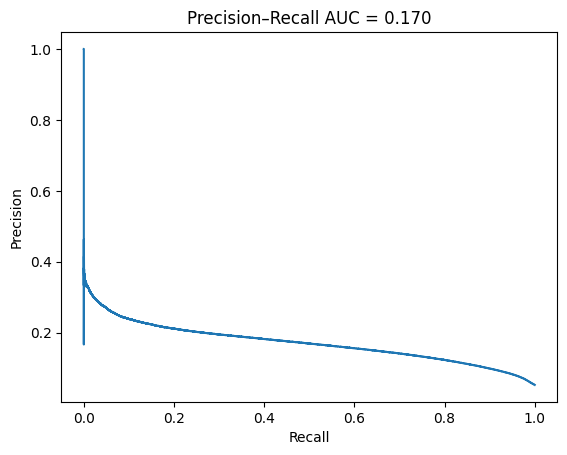

Precision@5% per day : 0.210
Overall recall        : 0.201
Avg picks per day     : 76.8

Confusion matrix (counts):
         Pred 0  Pred 1
True 0  4485177  193266
True 1   207966   52164

Confusion matrix (%):
        Pred 0 (%)  Pred 1 (%)
True 0       95.87        4.13
True 1       79.95       20.05

Accuracy         : 0.9188
Balanced acc     : 0.5796
AUC (probabilities): 0.8062
Positives in test : 5.27%
Picks at 5%       : 4.97%


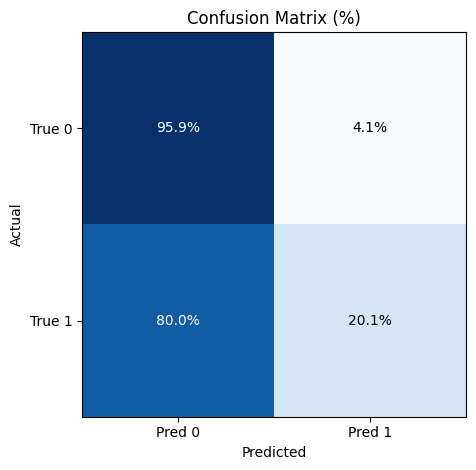

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    precision_recall_curve,
    auc
)
import matplotlib.pyplot as plt
# 1) Load predictions
df = pd.read_csv("full_test_predictions_top5.csv")

# 2) Precision–Recall curve (reference)
precision, recall, thresholds = precision_recall_curve(df["label"], df["prob"])
pr_auc = auc(recall, precision)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall AUC = {pr_auc:.3f}")
plt.show()

# 3) Ensure top-5% flag exists
if "pred_top5" not in df:
    df["rank_in_day"] = df.groupby("date")["prob"] \
                          .rank(method="first", ascending=False)
    def flag_top_frac(group, frac=0.05):
        k = max(1, int(len(group) * frac))
        idx = group.nsmallest(k, "rank_in_day").index
        s = pd.Series(0, index=group.index, dtype=int)
        s.loc[idx] = 1
        return s
    df["pred_top5"] = df.groupby("date", group_keys=False) \
                        .apply(flag_top_frac)

# 4) Compute metrics
hits_per_day  = df[df["pred_top5"] == 1].groupby("date")["label"].mean()
avg_precision = hits_per_day.mean()
overall_recall = (df["pred_top5"] & df["label"]).sum() / df["label"].sum()
avg_picks = df.groupby("date")["pred_top5"].sum().mean()

print(f"Precision@5% per day : {avg_precision:.3f}")
print(f"Overall recall        : {overall_recall:.3f}")
print(f"Avg picks per day     : {avg_picks:.1f}")

# 5) Confusion matrix
cm = confusion_matrix(df["label"], df["pred_top5"])
tn, fp, fn, tp = cm.ravel()
cm_pct = np.round(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100, 2)

print("\nConfusion matrix (counts):")
print(pd.DataFrame(cm, index=["True 0","True 1"], columns=["Pred 0","Pred 1"]))
print("\nConfusion matrix (%):")
print(pd.DataFrame(cm_pct, index=["True 0","True 1"], columns=["Pred 0 (%)","Pred 1 (%)"]))

print(f"\nAccuracy         : {(tn+tp)/cm.sum():.4f}")
print(f"Balanced acc     : {balanced_accuracy_score(df['label'], df['pred_top5']):.4f}")
print(f"AUC (probabilities): {roc_auc_score(df['label'], df['prob']):.4f}")
print(f"Positives in test : {df['label'].mean()*100:.2f}%")
print(f"Picks at 5%       : {df['pred_top5'].mean()*100:.2f}%")

# 6) Heatmap (optional)
fig, ax = plt.subplots()
im = ax.imshow(cm_pct, cmap="Blues")
for (i, j), val in np.ndenumerate(cm_pct):
    ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
            color="white" if val>cm_pct.max()/2 else "black")
ax.set_xticks([0,1])
ax.set_xticklabels(["Pred 0","Pred 1"])
ax.set_yticks([0,1])
ax.set_yticklabels(["True 0","True 1"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (%)")
plt.tight_layout()
plt.show()

## Scores

21% Accuracy
